In [ ]:
#Synthetic Particle Shower Classifier

In [4]:
!pip install torch torchvision shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import shap

#  Generate Synthetic Pythia vs Herwig Calorimeter Data
def generate_advanced_physics_data(num_samples=3000, grid_size=16):
    data = np.zeros((num_samples, 1, grid_size, grid_size), dtype=np.float32)
    labels = np.zeros(num_samples, dtype=np.int64)
    
    for i in range(num_samples):
        # Class 0: Simulating "Pythia" generator kinematics (Wider energy spread)
        if np.random.rand() > 0.5:
            data[i, 0, :, :] = np.random.normal(loc=0.1, scale=0.05, size=(grid_size, grid_size))
            labels[i] = 0
        # Class 1: Simulating "Herwig" generator kinematics (Tighter, denser energy cores)
        else:
            data[i, 0, :, :] = np.random.normal(loc=0.05, scale=0.02, size=(grid_size, grid_size))
            cx, cy = np.random.randint(5, 11, size=2)
            # Inject a dense high-energy core
            data[i, 0, cx-1:cx+2, cy-1:cy+2] += np.random.normal(loc=1.5, scale=0.3, size=(3, 3))
            labels[i] = 1
            
    return torch.tensor(np.clip(data, 0, None)), torch.tensor(labels)

X, y = generate_advanced_physics_data()
print(f"Generated {len(X)} synthetic collider events.")

Generated 3000 synthetic collider events.


In [5]:
# PyTorch Dataset and DataLoader
class PhysicsDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

dataset = PhysicsDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Advanced Neural Network with Regularization
class RobustCalorimeterCNN(nn.Module):
    def __init__(self):
        super(RobustCalorimeterCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), # Added Batch Norm
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Added Batch Norm
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)  # Added Spatial Dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.5),    # Added Standard Dropout
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RobustCalorimeterCNN().to(device)
print(f"Robust Model loaded onto: {device}")

Robust Model loaded onto: cuda


In [6]:
# Training Engine with AUC Tracking
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4) # Upgraded to AdamW

epochs = 12
print("Starting E2E Pipeline Training...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    # Validation Phase
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            # probabilities for class 1 (Herwig) via Softmax
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.numpy())
            
    # Calculate Physics Metrics
    val_auc = roc_auc_score(all_labels, all_preds)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {running_loss/len(train_loader):.4f} | Validation ROC-AUC: {val_auc:.4f}")

print("Training Complete. Model has successfully learned the Pythia vs Herwig representations.")

Starting E2E Pipeline Training...
Epoch [1/12] | Loss: 0.1278 | Validation ROC-AUC: 1.0000
Epoch [2/12] | Loss: 0.0017 | Validation ROC-AUC: 1.0000
Epoch [3/12] | Loss: 0.0009 | Validation ROC-AUC: 1.0000
Epoch [4/12] | Loss: 0.0005 | Validation ROC-AUC: 1.0000
Epoch [5/12] | Loss: 0.0007 | Validation ROC-AUC: 1.0000
Epoch [6/12] | Loss: 0.0005 | Validation ROC-AUC: 1.0000
Epoch [7/12] | Loss: 0.0003 | Validation ROC-AUC: 1.0000
Epoch [8/12] | Loss: 0.0011 | Validation ROC-AUC: 1.0000
Epoch [9/12] | Loss: 0.0002 | Validation ROC-AUC: 1.0000
Epoch [10/12] | Loss: 0.0002 | Validation ROC-AUC: 1.0000
Epoch [11/12] | Loss: 0.0001 | Validation ROC-AUC: 1.0000
Epoch [12/12] | Loss: 0.0001 | Validation ROC-AUC: 1.0000
Training Complete. Model has successfully learned the Pythia vs Herwig representations.


Generating SHAP Feature Importance Maps...
Red pixels increase the probability of the class. Blue pixels decrease it.


IndexError: index 1 is out of bounds for axis 0 with size 1

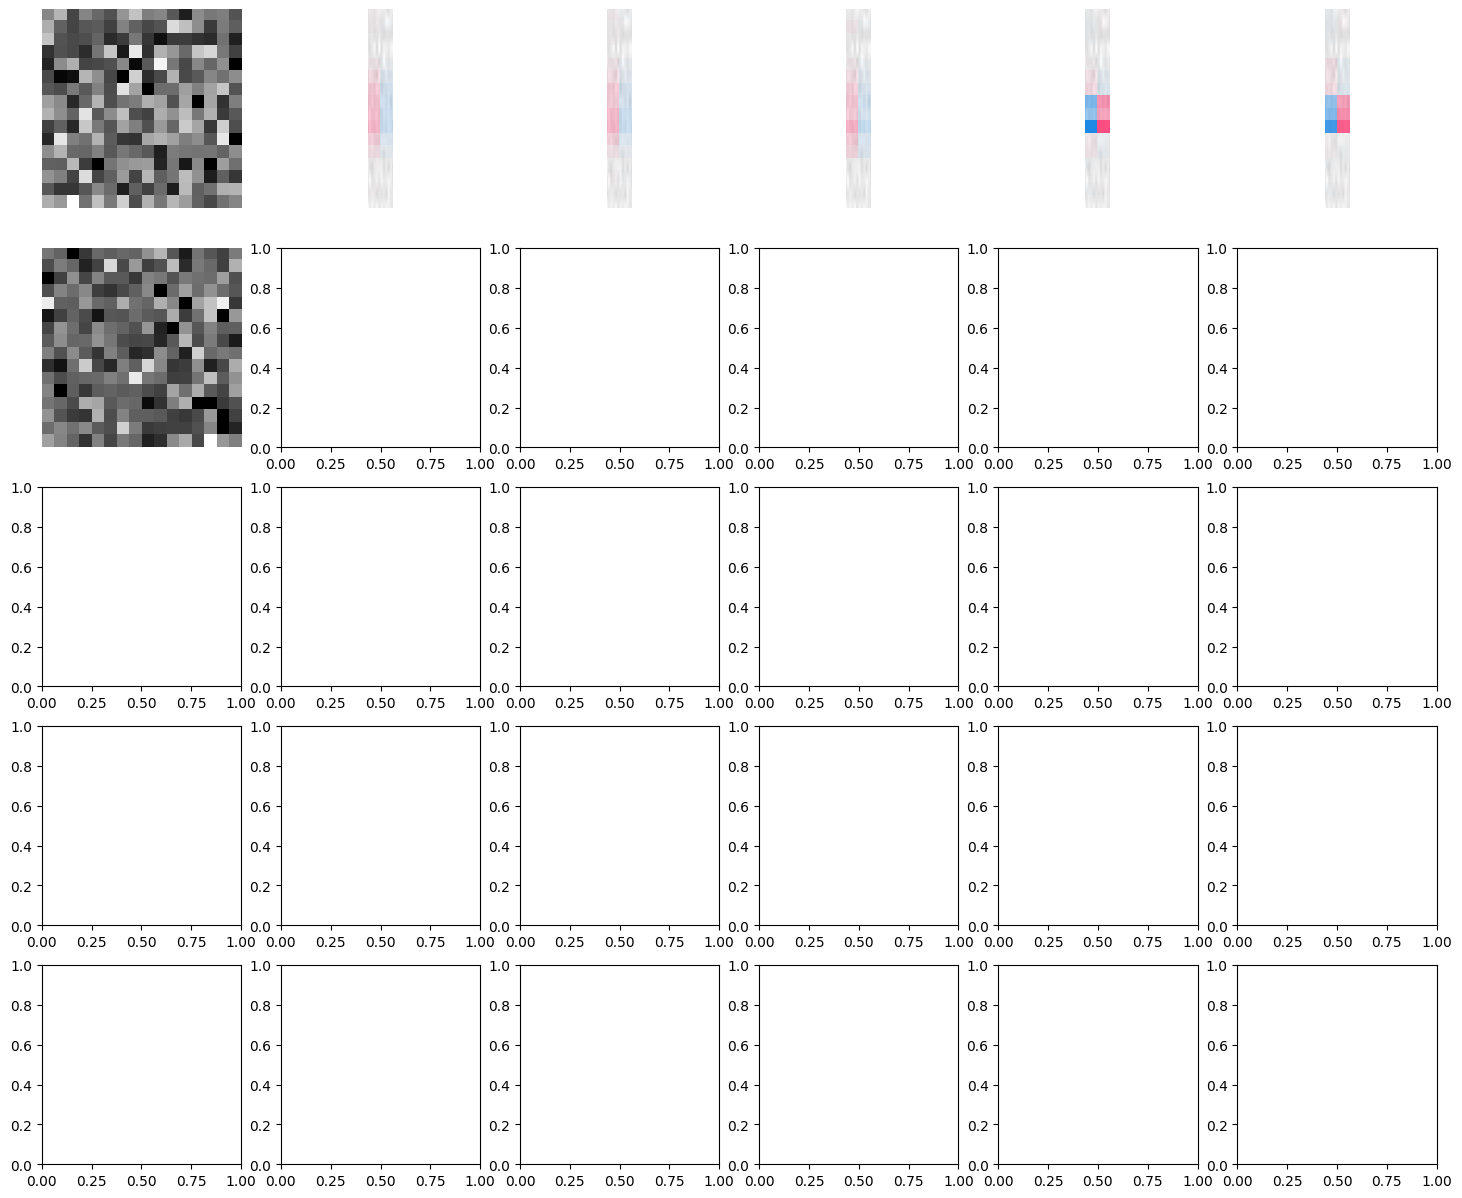

In [9]:
# Model Interpretability with SHAP
print("Generating SHAP Feature Importance Maps...")
model.eval()

background_data, _ = next(iter(train_loader))
background_data = background_data[:100].to(device)


test_images, test_labels = next(iter(val_loader))
test_images_sample = test_images[:5].to(device)

# Initialize the Explainer
explainer = shap.GradientExplainer(model, background_data)

shap_values = explainer.shap_values(test_images_sample)

shap_numpy = [np.transpose(s, (0, 2, 3, 1)) for s in shap_values]
test_numpy = np.transpose(test_images_sample.cpu().numpy(), (0, 2, 3, 1))

print("Red pixels increase the probability of the class. Blue pixels decrease it.")
shap.image_plot(shap_numpy, test_numpy)